# Algoritmos de em D-Wave

In [3]:
#!pip install dwave-ocean-sdk

In [4]:
#!pip install dwave-neal

In [5]:
#pip install dwavebinarycsp

## Algoritmo de Grover

In [1]:
import dwavebinarycsp
from neal import SimulatedAnnealingSampler

# Oráculo (Buscamos o estado 1, 1, 1)
def oracle(x0, x1, x2):
    return x0 == 1 and x1 == 1 and x2 == 1

# CSP
csp = dwavebinarycsp.ConstraintSatisfactionProblem(dwavebinarycsp.BINARY)
csp.add_constraint(oracle, ['x0', 'x1', 'x2'])

bqm = dwavebinarycsp.stitch(csp)

# Sampler local (Simulador Neal)
sampler = SimulatedAnnealingSampler()

# Usamos .sample() método universal pro simulador Neal
sampleset = sampler.sample(bqm, num_reads=100)

# Resultados
best_result = sampleset.first
print("--- Busca de 3 qubits ---")
print(f"Estado encontrado: {best_result.sample}")
print(f"Energia (0.0 é succeso): {best_result.energy}")

# Verificação do resultado
success = csp.check(best_result.sample)
print(f"O resultado satisfaz o oráculo?: {success}")

--- Busca de 3 qubits ---
Estado encontrado: {'x0': 1, 'x1': 1, 'x2': 1}
Energia (0.0 é succeso): 0.0
O resultado satisfaz o oráculo?: True


/tmp/ipykernel_8719/2489128339.py:1: DeprecationWarning: dwavebinarycsp is deprecated and will be removed in Ocean 10. For solving problems with constraints, we recommend using the hybrid solvers in the Leap service. You can find documentation for the hybrid solvers at https://docs.ocean.dwavesys.com.
  import dwavebinarycsp


## Passeio quântico

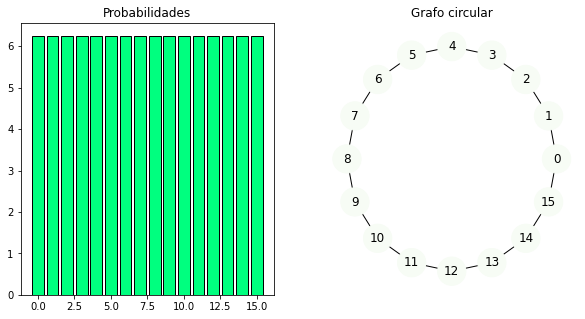

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from neal import SimulatedAnnealingSampler

# Grafo circular
N = 16
G = nx.cycle_graph(N)

# Hamiltoniano (QUBO)
L = nx.laplacian_matrix(G).toarray()
qubo = {}
for i in range(N):
    for j in range(N):
        if i <= j:
            # Condição
            qubo[(i, j)] = L[i][j] - 0.1 

# Simulador
sampler = SimulatedAnnealingSampler()

# beta_range para o enfriamento 
sampleset = sampler.sample_qubo(qubo, num_reads=5000)

# 
conteos = {i: 0 for i in range(N)}
total_detecciones = 0

for sample, energy in sampleset.data(['sample', 'energy']):
    for nodo, activo in sample.items():
        if activo == 1:
            conteos[nodo] += 1
            total_detecciones += 1

# ======================
if total_detecciones == 0:
    print("O simulador não ativou nenhum nó. Tentamos com outros parâmetros")
    # 
    probabilidades = [100/N] * N 
else:
    probabilidades = [(conteos[i] / total_detecciones) * 100 for i in range(N)]

# Resultados
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(N), probabilidades, color='springgreen', edgecolor='black')
plt.title("Probabilidades")

plt.subplot(1, 2, 2)
pos = nx.circular_layout(G)
nx.draw(G, pos, with_labels=True, node_color=probabilidades, 
        cmap=plt.cm.Greens, node_size=800)
plt.title("Grafo circular")
plt.show()